We will stick to the row major order to align with numpy. This means our "dense" layers will be

$$\bold{Y} = \bold{X}\bold{W} + \bold{b}$$

Where $\bold{X}$ is the row vector in question. Might implement a technique called batching in the future.

In [1]:
import Tensor as t
import numpy as np
import matplotlib.pyplot as plt
import Operations as o
import Compile as c
from sklearn.datasets import fetch_openml
# Fetch the MNIST dataset (this might take a minute to download)
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# Split into features (images) and labels
X, y = mnist["data"], mnist["target"]

print(f"Dataset shape: {X.shape}")

#encoding values
def encode(val):
    z = np.zeros(10,dtype=np.float64)
    z[int(val)] += 1.0
    return z

#hot encoding
y_cleaned = np.array([np.array([encode(k)]) for k in y]) #cleaned dataset shape: (70_000,1,10)
print(f"cleaned dataset shape: {y_cleaned.shape}")

#normalization
x_cleaned = X.astype(np.float64) / 255
#reshaping
x_cleaned = x_cleaned.reshape((70_000,1,784)) # cleaned input shape: (70_000,1,10)
print(f"cleaned input shape: {x_cleaned.shape}")


Dataset shape: (70000, 784)
cleaned dataset shape: (70000, 1, 10)
cleaned input shape: (70000, 1, 784)


In [2]:
#train test split
TRAIN_AMOUNT = 50_000
#batching experimentation
x_train, x_test = np.split(np.sum(x_cleaned,axis=1),[TRAIN_AMOUNT]) #cleaned train x shape: (50_000,784) and clean test x shape: (20_000,784)
print(f"cleaned train x shape: {x_train.shape} and clean test x shape: {x_test.shape}")

y_train, y_test = np.split(np.sum(y_cleaned,axis=1),[TRAIN_AMOUNT]) #cleaned train y shape: (50_000,10) and clean test y shape: (20_000,10)
print(f"cleaned train y shape: {y_train.shape} and clean test y shape: {y_test.shape}")

cleaned train x shape: (50000, 784) and clean test x shape: (20000, 784)
cleaned train y shape: (50000, 10) and clean test y shape: (20000, 10)


In [3]:
#batching
BATCH_AMOUNT = 1_000
x_train_batched = np.array(np.split(x_train, BATCH_AMOUNT))  #batched train x shape: (BATCH_AMOUNT,50000/BATCH_AMOUNT,784)
print(f"batched train x shape: {x_train_batched.shape}")

y_train_batched = np.array(np.split(y_train, BATCH_AMOUNT)) #batched train y shape: (BATCH_AMOUNT,50000/BATCH_AMOUNT,10)
print(f"batched train y shape: {y_train_batched.shape}")

batched train x shape: (1000, 50, 784)
batched train y shape: (1000, 50, 10)


In [23]:
#current architecture: Dense(784 15) sAct softmax Dense(15 10) sAct softmax (done!)
#paramaters
w_1 = t.TensorNode(0.01*np.random.random_sample(size=(784, 15)))
b_1 = t.TensorNode(0.01*np.random.random_sample(size=(1,15)))

w_2 = t.TensorNode(0.01*np.random.random_sample(size=(15,10)))
b_2 = t.TensorNode(0.01*np.random.random_sample(size=(1,10)))


In [24]:
#the input change this in order to change the input
#current architecture: Dense, softmax, Dense, softmax

x_value = t.TensorNode(x_cleaned[0],is_param=False)

L_1 = x_value @ w_1 + b_1
L_1 = (o.sAct(L_1)) # change to o.sAct when MSE


L_2 = L_1 @ w_2 + b_2

#model variable -- use this to peek at output
model = o.exp(L_2)

model = model/o.sum(model,axis=1,keepDim=True)


y_value = t.TensorNode(y_cleaned[0],is_param=False)

# #MSE MODE
# loss = o.norm_squared(model - y_value)
# comp = c.Pipeline(loss.compile())


# cross-entropy mode
loss = o.softmaxCrossEntropy(L_2,y_value,axis=1)
comp = c.Pipeline(loss.compile())

In [25]:
#total loss
def total_loss():
    x_value.update_data(x_train)
    y_value.update_data(y_train)
    comp.update_input()
    print(f"loss + {loss.data}")
    return loss.data

In [26]:
#iterative gradient descent
def iterative_train(lr =  3):
    total.append(total_loss())

    for j in range(TRAIN_AMOUNT):
        x_value.update_data(x_cleaned[j])
        y_value.update_data(y_cleaned[j])
        comp.update_input()
        comp.train()
        comp.update(lr)

    total.append(total_loss())

In [27]:
#batch based gradient descent


def batch_train(lr = 3):
    for j in range(BATCH_AMOUNT):
        x_value.update_data(x_train_batched[j])
        y_value.update_data(y_train_batched[j])
        comp.update_input()
        comp.train()
        comp.update(lr)

    total.append(total_loss())


WE DID IT. Below is the accuracy:

In [50]:
def band_aid_softmax(inp: np.ndarray):
    z = np.exp(inp)
    return z/np.sum(z)

In [46]:
#accuracy measurement. 
def test_model():
    correct = 0
    for j in range(50_000):
        x_value.update_data(x_cleaned[j])
        y_value.update_data(y_cleaned[j])
        comp.update_input()
        if(str(np.argmax(band_aid_softmax(L_2.data))) == y[j]):
            correct+=1

    print("Raw correct: " + str(correct))
    print("accruacy " + str(correct/50_000))

    train = correct
    print("test dataset:")
    correct = 0
    for j in range(50_001,70_000):
        x_value.update_data(x_cleaned[j])
        y_value.update_data(y_cleaned[j])
        comp.update_input()
        if(str(np.argmax(band_aid_softmax(L_2.data))) == y[j]):
            correct+=1

    print("Raw correct: " + str(correct))
    print("accruacy " + str(correct/20_000))
    return [train, correct]


In [29]:
#array containing all losses
total = []

playground

In [82]:
for j in range(100):
    batch_train(2*1e-3)
    if(total[-1] > total[-2]):
        break

loss + 4793.734417376707
loss + 4780.143632775429
loss + 4766.534257871065
loss + 4752.964681007909
loss + 4739.445341254231
loss + 4725.977028599367
loss + 4712.569074304628
loss + 4699.172210137997
loss + 4685.768960362538
loss + 4672.4370511326715
loss + 4659.2550628432855
loss + 4646.346657441012
loss + 4633.5653996373985
loss + 4620.825948248769
loss + 4608.363299390341
loss + 4595.816596204646
loss + 4583.170374037985
loss + 4570.469828252053
loss + 4557.926325606597
loss + 4545.44704406082
loss + 4532.960485695083
loss + 4520.602161880815
loss + 4508.422300040891
loss + 4496.368717104299
loss + 4484.539765234149
loss + 4472.869498565584
loss + 4461.437488949546
loss + 4450.264368199012
loss + 4439.316292368914
loss + 4428.760949394466
loss + 4418.495296768153
loss + 4408.541157505087
loss + 4399.124621944495
loss + 4390.227451273793
loss + 4382.017669472546
loss + 4373.8227447110485
loss + 4365.681038339036
loss + 4357.473034533361
loss + 4349.224307775246
loss + 4340.9985404605

In [83]:
test_model()

Raw correct: 48672
accruacy 0.97344
test dataset:
Raw correct: 18852
accruacy 0.9426


[48672, 18852]

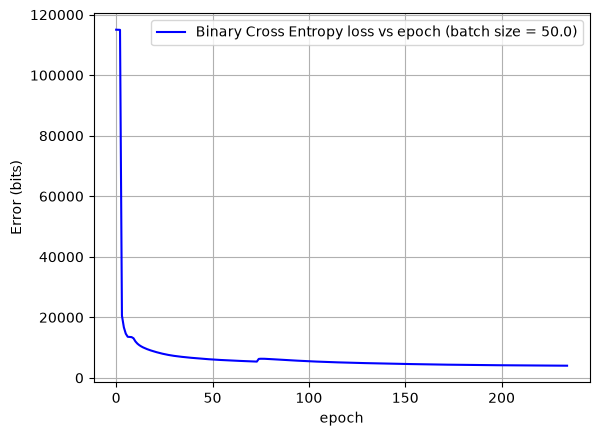

In [85]:
plt.plot(total,label=f'Binary Cross Entropy loss vs epoch (batch size = {TRAIN_AMOUNT/BATCH_AMOUNT})',color='blue')
plt.xlabel("epoch")
plt.ylabel("Error (bits)")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
for j in range(5):
    batch_train(0.5)

loss + 205518.40575511937
loss + 172540.3667374504
loss + 175391.49680724152
loss + 239067.79441930668
loss + 219226.19042310023
